In [34]:
from google.colab import files
uploaded = files.upload()

Saving E Commerce Dataset.xlsx to E Commerce Dataset (6).xlsx


In [35]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_excel(filename, sheet_name='E Comm')

print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [36]:
!pip install openpyxl -q

In [37]:
print(df.isnull().sum())
print()
print(df.dtypes)
print()
print("Churn rate:", df['Churn'].mean().round(3))

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender       

In [38]:
df_clean = df.drop(columns=['CustomerID'])

# Fill numeric missing values with median
numeric_cols = df_clean.select_dtypes(include='number').columns
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# One-hot encode categorical columns
categorical_cols = df_clean.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(5630, 30)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,False,True,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,True,False,False,True,False,False,False,True


In [39]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (4504, 29)
Test set: (1126, 29)


In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba).round(3))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       0.99      0.87      0.93       190

    accuracy                           0.98      1126
   macro avg       0.98      0.93      0.96      1126
weighted avg       0.98      0.98      0.98      1126

ROC-AUC Score: 0.999

Confusion Matrix:
[[935   1]
 [ 25 165]]


In [42]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

Tenure                         0.246185
CashbackAmount                 0.101351
Complain                       0.065971
WarehouseToHome                0.064300
DaySinceLastOrder              0.059437
NumberOfAddress                0.053601
OrderAmountHikeFromlastYear    0.050782
SatisfactionScore              0.048583
NumberOfDeviceRegistered       0.031577
OrderCount                     0.028712
dtype: float64


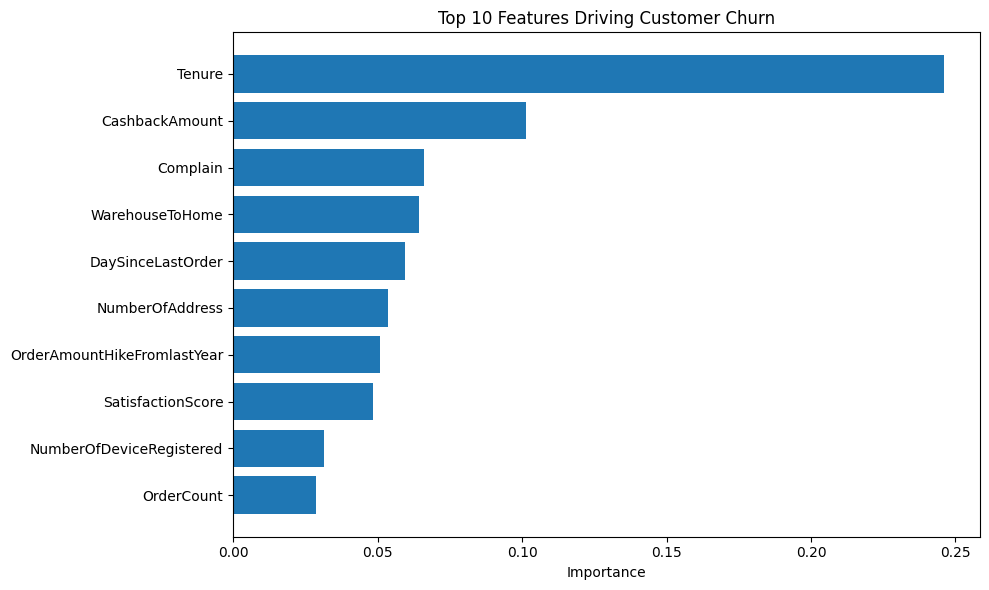

In [43]:
import matplotlib.pyplot as plt

top_features = importances.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features Driving Customer Churn')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

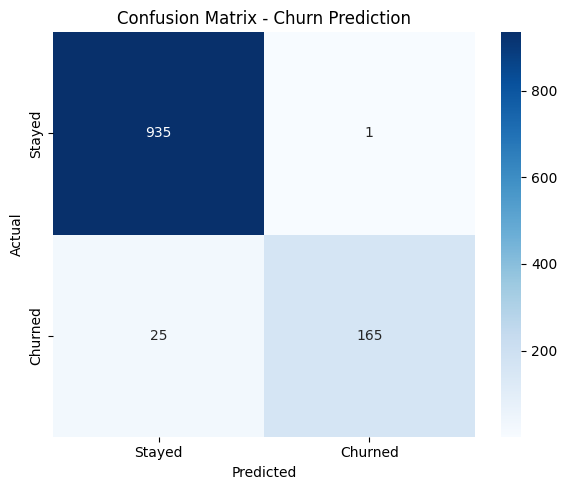

In [44]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Churn Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [45]:
from google.colab import files

files.download('feature_importance.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>